# Chronos-2 튜토리얼(기본 사전학습 파라미터 이용)

In [ ]:
# 아래의 패키지 설치가 필요함(주석 표시 제거 후 이용)
# %pip install "chronos-forecasting >= 2.0"

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

from chronos import Chronos2Pipeline

In [ ]:
# 시뮬레이션 데이터 생성
rng   = np.random.default_rng(0)
dates = pd.date_range("2000-01-01", "2025-12-31", freq = "D")
price = 1000 + 100 * np.sin(2 * np.pi * (dates.dayofyear - 160) / 365) + rng.normal(0, 10, len(dates))
df    = pd.DataFrame({"date": dates, "price": price.round(1)})

In [ ]:
# 데이터 확인
plt.figure(figsize = (18, 4))
plt.plot(df["date"], df["price"], lw = 0.5, color = "#000000")
plt.show()

In [ ]:
# Chronos-2 파이프라인 불러오기
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map = "cpu")

In [ ]:
# 모형 구조 확인
print(pipeline.model)

In [ ]:
# 모형 설정 확인
print(pipeline.model.config)

In [ ]:
# 모형 내 pre-trained 가중치 확인
weight = dict(pipeline.model.named_parameters())
print(weight)

In [ ]:
# 예측 수행 시점
pred_origin = "2023-12-31"

In [ ]:
# 입력 기간 데이터(2000-01-01 ~ 2023-12-31)
hist = df[df["date"] <= pred_origin]

In [30]:
# 예측 대상 기간 데이터(2024-01-01 ~ 2025-12-31)
actual = df[(df["date"] > pred_origin) & (df["date"] <= "2025-12-31")]

In [32]:
# 예측 대상 기간의 길이
horizon = len(actual)

In [33]:
# 입력데이터
context = hist["price"].to_numpy(dtype = np.float32)

In [ ]:
# 예측 수행(별도의 학습 없이 사전 학습된 모형 그대로 예측 수행)
quantiles, _ = pipeline.predict_quantiles(
    inputs            = [context],
    prediction_length = horizon,
    quantile_levels   = [0.1, 0.5, 0.9] # 예측하고자 하는 quantiles
)

In [ ]:
# q에 총 731일에 대해서 3개의 quantiles 예측값 저장
q = quantiles[0][0].numpy()
q.shape

(731, 3)

In [ ]:
# 예측 대상 날짜
fc_dates = actual["date"].to_numpy()

In [40]:
# 예측 결과
fc = pd.DataFrame({"date": fc_dates, "q10": q[:, 0], "q50": q[:, 1], "q90": q[:, 2]})

In [41]:
# 실제값
fc["actual"] = actual["price"].to_numpy()

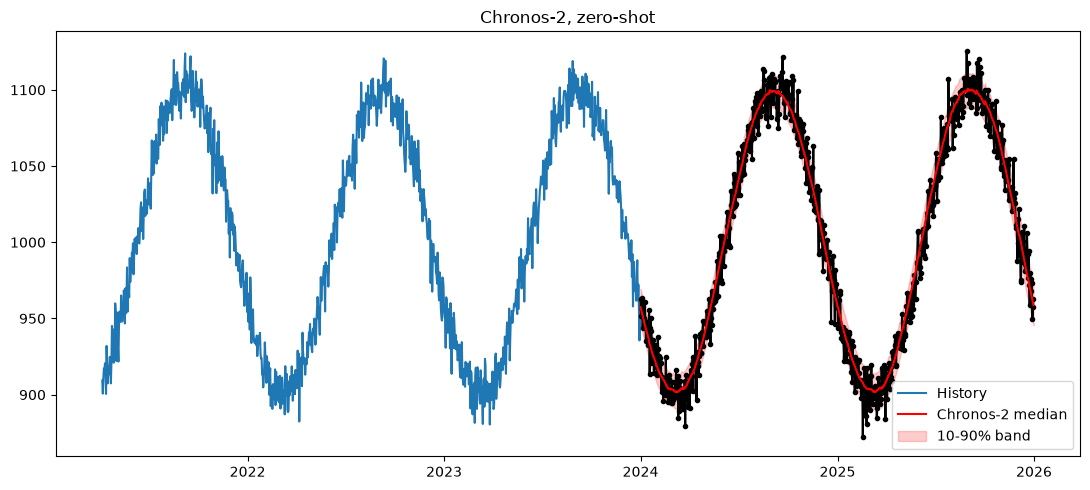

In [47]:
# 예측결과 그림
recent = hist.tail(1000)
plt.figure(figsize=(11, 5))
plt.plot(recent["date"], recent["price"], label="History")
if "actual" in fc:
    plt.plot(fc["date"], fc["actual"], "k.-")
plt.plot(fc["date"], fc["q50"], "r-", label = "Chronos-2 median")
plt.fill_between(fc["date"], fc["q10"], fc["q90"], color = "r", alpha = 0.2, label = "10-90% band")
plt.title("Chronos-2, zero-shot")
plt.legend()
plt.tight_layout()
plt.show()

# Chronos-2 튜토리얼(미세 조정된 파라미터 이용)

In [48]:
import urllib.request
from pathlib import Path

In [49]:
ckpt_url = "https://github.com/econompark/Center-for-Agricultural-Outlook/releases/download/ckpt-chronos2"

In [53]:
# 미세 조정된 파라미터를 저장할 경로 입력 및 폴더 생성
ckpt_dir = Path("ckpt_chronos2")
ckpt_dir.mkdir(exist_ok = True)

In [54]:
# 파일 저장하기(저장 위치 = 위 셀에서 설정한 폴더)
for f in ["config.json", "model.safetensors"]:
    if not (ckpt_dir / f).exists():
        urllib.request.urlretrieve(f"{ckpt_url}/{f}", ckpt_dir / f)

In [56]:
# 미세 조정된 파라미터 및 Chronos-2 파이프라인 불러오기
pipeline2 = Chronos2Pipeline.from_pretrained(str(ckpt_dir), device_map = "cpu")

In [57]:
# Chronos-2 모형 기본, 새 파이프라인에 저장된 모형 확인 (자명하게, 둘은 동일해야함)
print("\n".join(str(pipeline.model).splitlines()[:10]))
print("=" * 100)
print("\n".join(str(pipeline2.model).splitlines()[:10]))

Chronos2Model(
  (shared): Embedding(2, 768)
  (input_patch_embedding): ResidualBlock(
    (dropout): Dropout(p=0.1, inplace=False)
    (hidden_layer): Linear(in_features=48, out_features=3072, bias=True)
    (act): ReLU()
    (output_layer): Linear(in_features=3072, out_features=768, bias=True)
    (residual_layer): Linear(in_features=48, out_features=768, bias=True)
  )
  (patch): Patch()
Chronos2Model(
  (shared): Embedding(2, 768)
  (input_patch_embedding): ResidualBlock(
    (dropout): Dropout(p=0.1, inplace=False)
    (hidden_layer): Linear(in_features=48, out_features=3072, bias=True)
    (act): ReLU()
    (output_layer): Linear(in_features=3072, out_features=768, bias=True)
    (residual_layer): Linear(in_features=48, out_features=768, bias=True)
  )
  (patch): Patch()


In [59]:
# Chronos-2 기본 파이프라인, 새 파이프라인에 저장된 설정 확인 (자명하게, 둘은 동일해야함)
print("\n".join(str(pipeline.model.config).splitlines()[:10]))
print("=" * 100)
print("\n".join(str(pipeline2.model.config).splitlines()[:10]))

Chronos2CoreConfig {
  "architectures": [
    "Chronos2Model"
  ],
  "chronos_config": {
    "context_length": 8192,
    "input_patch_size": 16,
    "input_patch_stride": 16,
    "max_output_patches": 64,
    "output_patch_size": 16,
Chronos2CoreConfig {
  "architectures": [
    "Chronos2Model"
  ],
  "chronos_config": {
    "context_length": 8192,
    "input_patch_size": 16,
    "input_patch_stride": 16,
    "max_output_patches": 64,
    "output_patch_size": 16,


In [60]:
# Chronos-2 기본 파이프라인, 새 파이프라인에 저장된 가중치 확인 (약간의 차이가 존재해야함)
weight2 = dict(pipeline2.model.named_parameters())
print("\n".join(str(weight).splitlines()[:10]))
print("=" * 100)
print("\n".join(str(weight2).splitlines()[:10]))

{'shared.weight': Parameter containing:
tensor([[-1.4855e-06,  6.6741e-07, -2.3774e-07,  ...,  2.5759e-07,
          1.6342e-06,  2.2832e-06],
        [-2.4927e-03,  3.1087e-03,  1.2331e-03,  ..., -1.2153e-02,
         -7.9643e-04, -9.8041e-03]], requires_grad=True), 'input_patch_embedding.hidden_layer.weight': Parameter containing:
tensor([[-1.6344e-03, -1.7315e-03, -1.7230e-03,  ..., -6.8476e-03,
         -1.5899e-03, -7.6784e-03],
        [ 1.5054e-04,  1.0679e-04,  2.0166e-04,  ...,  3.2022e-03,
          3.9019e-03,  3.4222e-03],
        [-8.2940e-04, -8.7882e-04, -8.5499e-04,  ..., -3.6055e-03,
{'shared.weight': Parameter containing:
tensor([[-1.4855e-06,  6.6741e-07, -2.3774e-07,  ...,  2.5759e-07,
          1.6342e-06,  2.2832e-06],
        [-2.4752e-03,  3.1264e-03,  1.2575e-03,  ..., -1.2149e-02,
         -7.5843e-04, -9.7565e-03]], requires_grad=True), 'input_patch_embedding.hidden_layer.weight': Parameter containing:
tensor([[-1.6395e-03, -1.7366e-03, -1.7280e-03,  ..., -6.

In [61]:
# 예측 수행
quantiles, _ = pipeline2.predict_quantiles(
    inputs            = [context],
    prediction_length = horizon,
    quantile_levels   = [0.1, 0.5, 0.9]
)
q = quantiles[0][0].numpy()
q.shape

(731, 3)

In [62]:
# 결과 정리
fc_dates = actual["date"].to_numpy()
fc = pd.DataFrame({"date": fc_dates, "q10": q[:, 0], "q50": q[:, 1], "q90": q[:, 2]})
fc["actual"] = actual["price"].to_numpy()

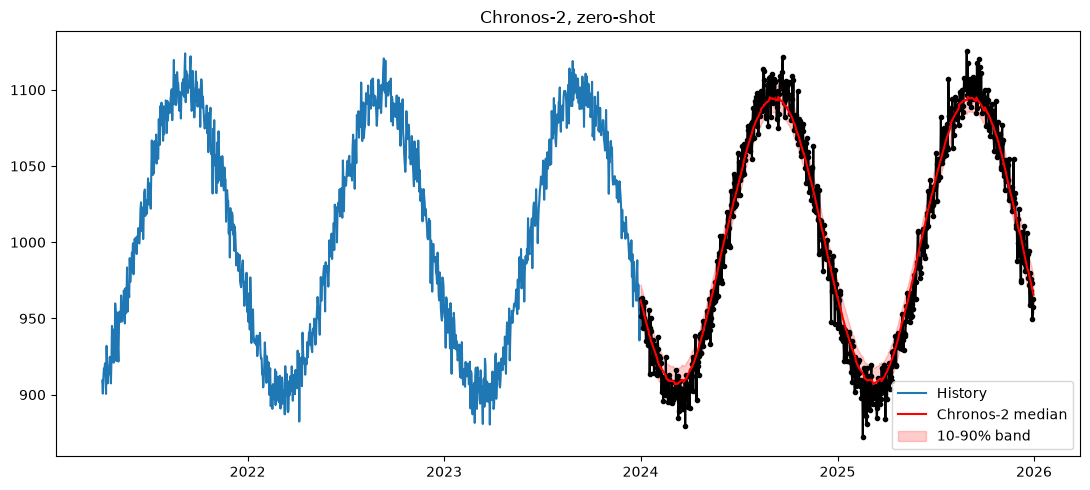

In [ ]:
# 예측결과 그림: 현재 예측하고자 하는 데이터의 패턴이 매우 단순하고 미세 조정이 현재 예측의 대상인 데이터를 이용하여 이루어지지 않아 이전의 것과 거의 같은 결과를 보여줌
# 데이터의 패턴이 보다 복잡하고 미세 조정을 예측 대상 데이터로 수행하는 경우 큰 성능 향상을 기대할 수 있음.
recent = hist.tail(1000)
plt.figure(figsize=(11, 5))
plt.plot(recent["date"], recent["price"], label="History")
if "actual" in fc:
    plt.plot(fc["date"], fc["actual"], "k.-")
plt.plot(fc["date"], fc["q50"], "r-", label = "Chronos-2 median")
plt.fill_between(fc["date"], fc["q10"], fc["q90"], color = "r", alpha = 0.2, label = "10-90% band")
plt.title("Chronos-2, zero-shot")
plt.legend()
plt.tight_layout()
plt.show()